# Movie Recommender

In [5]:
!pip cache purge --quiet

In [6]:
!pip install matplotlib==3.10.5 \
             scikit-learn==1.7.1 \
             scikit-surprise==1.1.5 \
             seaborn==0.13.2 \
             wordcloud==1.9.4 --quiet

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
import sklearn.metrics as metrics
import zipfile

from surprise import accuracy, Dataset, Reader, SVD
from surprise.model_selection import GridSearchCV, train_test_split
from wordcloud import WordCloud, STOPWORDS

INFO:matplotlib.font_manager:generated new fontManager


In [9]:
# If you've forked this repo, change OWNER to your GitHub username.
# REPO and BRANCH will normally stay the same unless you renamed them.
OWNER = "singlestore-cookbook"
REPO = "singlestore-cookbook.github.io"
BRANCH = "refs/heads/main"

BASE_URL = f"https://raw.githubusercontent.com/{OWNER}/{REPO}/{BRANCH}/code/part-ml/movie-recommender/datasets"

In [10]:
zip_url = f"{BASE_URL}/archive.zip"

response = requests.get(zip_url)
response.raise_for_status()

with open("archive.zip", "wb") as f:
    f.write(response.content)

with zipfile.ZipFile("archive.zip", "r") as z:
    print(z.namelist())
    for filename in ["users.dat", "movies.dat", "ratings.dat"]:
        z.extract(filename)

['movies.dat', 'ratings.dat', 'users.dat']


In [11]:
movies_csv_url = "movies.dat"

movies_df = pd.read_csv(
    movies_csv_url,
    engine = "python",
    sep = "::",
    header = None,
    encoding = "latin1",
    names = ["id", "title", "genres"]
)

In [12]:
movies_df.head()

,id,title,genres
0,1,Fiasco on the Suzanne Spurs (1988),Comedy
1,2,Computer Whisper (1999),Romance|Adventure
2,3,The Case of Katherine Wolfe (1986),Animation
3,4,Live Party (1980),Comedy|Drama
4,5,Word Smile (2020),Drama|Action


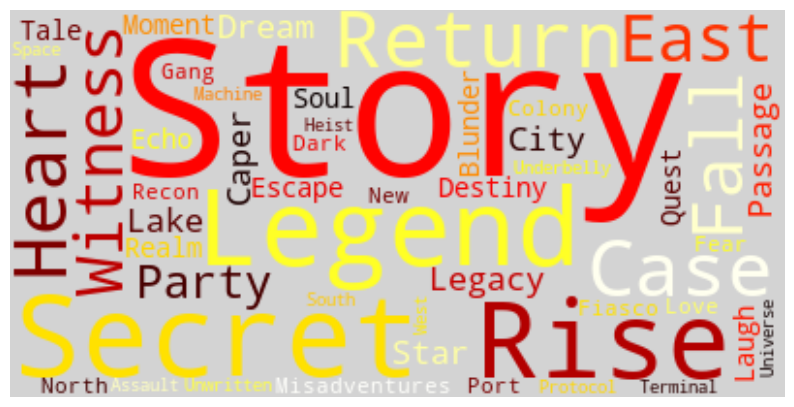

In [13]:
movie_titles_list = movies_df["title"].tolist()
movie_titles_corpus = " ".join(movie_titles_list)

wordcloud = WordCloud(
    stopwords = STOPWORDS,
    background_color = "lightgrey",
    colormap = "hot",
    max_words = 50,
    # collocations = False
).generate(movie_titles_corpus)

plt.figure(figsize = (10, 8))
plt.imshow(wordcloud, interpolation = "bilinear")
plt.axis("off")
plt.show()

In [14]:
users_csv_url = "users.dat"

users_df = pd.read_csv(
    users_csv_url,
    engine = "python",
    sep = "::",
    header = None,
    encoding = "latin1",
    names = ["id", "gender", "age", "occupation", "zip_code"]
)

In [15]:
users_df.head()

,id,gender,age,occupation,zip_code
0,1,M,50,self-employed,62882
1,2,F,1,programmer,71982
2,3,M,1,scientist,52243
3,4,M,50,college/grad student,85978
4,5,F,25,college/grad student,93934


In [16]:
result = (
    users_df.groupby("gender")
    .size()
    .reset_index(name = "count")
)

print(result.to_string(index = False))

gender  count
     F   1738
     M   4302


In [17]:
result = (
    users_df.groupby("occupation")
    .size()
    .reset_index(name = "count")
    .sort_values(by = "count", ascending = False)
    .head(21)
)

print(result.to_string(index = False))

          occupation  count
college/grad student    732
executive/managerial    700
               other    689
 technician/engineer    514
   academic/educator    511
          programmer    405
              artist    278
     sales/marketing    276
              writer    264
       self-employed    242
  doctor/health care    227
      clerical/admin    195
        K-12 student    195
           scientist    156
             retired    144
              lawyer    136
    customer service    131
           homemaker    116
 tradesman/craftsman     60
          unemployed     53
              farmer     16


In [18]:
ratings_csv_url = "ratings.dat"

ratings_df = pd.read_csv(
    ratings_csv_url,
    engine = "python",
    sep = "::",
    header = None,
    encoding = "latin1",
    names = ["user_id", "movie_id", "rating", "timestamp"]
)

In [19]:
result = ratings_df[["user_id", "movie_id", "rating"]].describe()
print(result.round(2))

          user_id    movie_id      rating
count  1000209.00  1000209.00  1000209.00
mean      3017.87     1761.53        3.61
std       1742.61     1156.55        0.72
min          1.00        2.00        1.00
25%       1515.00      650.00        3.00
50%       3011.00     1781.00        4.00
75%       4525.00     2678.00        4.00
max       6040.00     3945.00        5.00


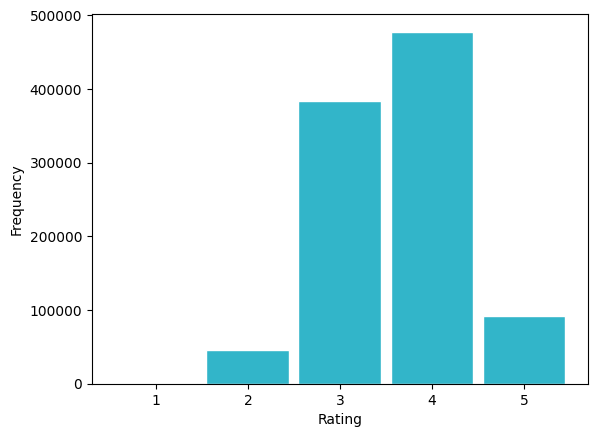

In [20]:
ratings_df["rating"].plot.hist(
    edgecolor = "white",
    color = "#32B5C9",
    rwidth = 0.9,
    bins = [0.5, 1.5, 2.5, 3.5, 4.5, 5.5]
)

plt.ylabel("Frequency")
plt.xlabel("Rating")
plt.show()

In [21]:
reader = Reader(rating_scale = (1, 5))
data = Dataset.load_from_df(
    ratings_df[["user_id", "movie_id", "rating"]],
    reader
)

train, test = train_test_split(
    data,
    test_size = 0.3,
    random_state = 42
)

# Set default values for best_params
best_params = {
    "n_factors": 100,
    "reg_all": 0.05,
    "n_epochs": 40
}

In [22]:
# param_grid = {
#     "n_factors": [50, 100, 150, 200],
#     "reg_all": [0.01, 0.02, 0.05, 0.1],
#     "n_epochs": [10, 20, 30, 40]
# }

# # Define the grid search with the model and parameter grid
# gs = GridSearchCV(SVD, param_grid, measures = ["rmse", "mae"], cv = 3)

# # Run the grid search on the data
# gs.fit(data)

# # Get the best parameters
# best_params = gs.best_params["rmse"]

# # Print the best RMSE score and best parameters
# print(f"Best RMSE score: {gs.best_score['rmse']}")
# print(f"Best parameters: {best_params}")

In [23]:
# Initialize the SVD model with the best parameters
model = SVD(
    n_factors = best_params["n_factors"],
    reg_all = best_params["reg_all"],
    n_epochs = best_params["n_epochs"],
    random_state = 0
)

model.fit(train)

In [24]:
predictions = model.test(test)

predictions_df = pd.DataFrame(
    predictions,
    columns = ["user_id", "movie_id", "rating", "prediction", "details"]
)

predictions_df = predictions_df.drop(columns = ["details"])

predictions_df.head()

,user_id,movie_id,rating,prediction
0,2934,3594,3.0,3.184101
1,5706,1535,4.0,4.165922
2,5251,1283,4.0,3.390595
3,5683,3186,5.0,4.247155
4,1120,1012,5.0,4.188839


In [25]:
rmse = accuracy.rmse(predictions)
mae = accuracy.mae(predictions)
mse = accuracy.mse(predictions)
fcp = accuracy.fcp(predictions)

RMSE: 0.4085
MAE:  0.3207
MSE: 0.1669
FCP:  0.9411


In [26]:
# Get true ratings and estimated ratings
y_true = [true_r for (_, _, true_r, _, _) in predictions]
y_pred = [est for (_, _, _, est, _) in predictions]

# Convert continuous ratings to binary labels
threshold = 3.5
y_true_binary = [1 if rating >= threshold else 0 for rating in y_true]
y_pred_binary = [1 if rating >= threshold else 0 for rating in y_pred]

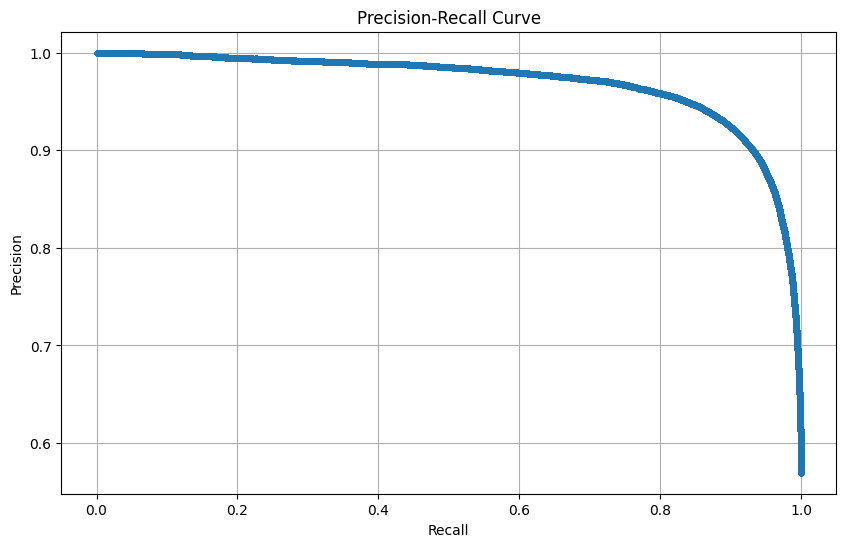

In [27]:
precision, recall, _ = metrics.precision_recall_curve(y_true_binary, y_pred)
plt.figure(figsize = (10, 6))
plt.plot(
    recall,
    precision,
    marker = "."
)

plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")

plt.grid(True)
plt.show()

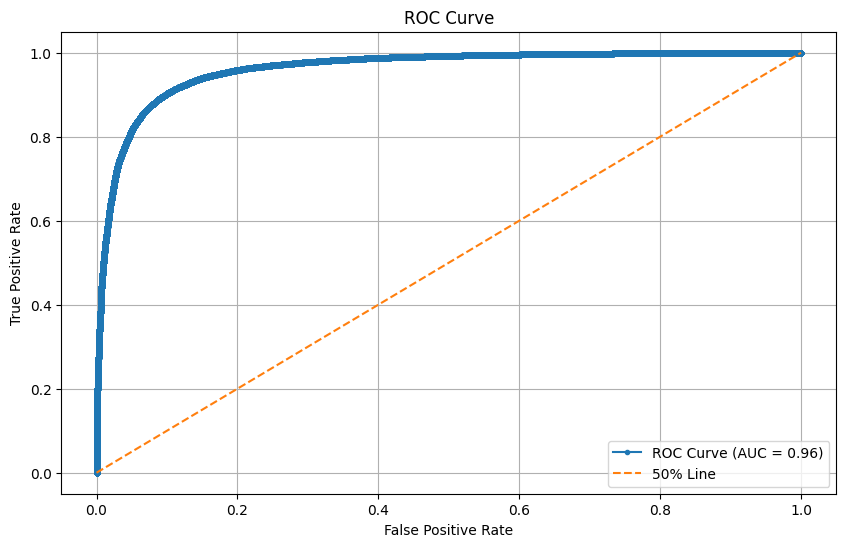

In [28]:
fpr, tpr, _ = metrics.roc_curve(y_true_binary, y_pred)
roc_auc = metrics.auc(fpr, tpr)
plt.figure(figsize = (10, 6))
plt.plot(
    fpr,
    tpr,
    marker = ".",
    label = f"ROC Curve (AUC = {roc_auc:.2f})"
)
plt.plot(
    [0, 1],
    [0, 1],
    linestyle = "--",
    label = "50% Line"
)

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.grid(True)
plt.show()

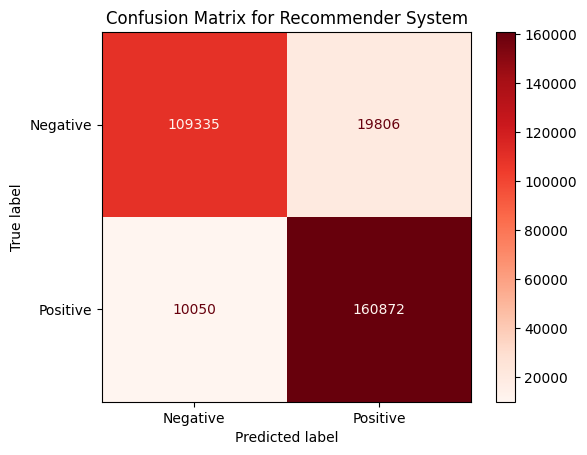

In [29]:
# Calculate the confusion matrix
cm = metrics.confusion_matrix(y_true_binary, y_pred_binary)

# Define labels for the plot
labels = ["Negative", "Positive"]

# Display the confusion matrix using the streamlined method
disp = metrics.ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = labels)
disp.plot(cmap = "Reds", values_format = "d")
plt.title("Confusion Matrix for Recommender System")
plt.show()

In [30]:
print("Accuracy :", metrics.accuracy_score(y_true_binary, y_pred_binary))
print("Precision:", metrics.precision_score(y_true_binary, y_pred_binary))
print("Recall   :", metrics.recall_score(y_true_binary, y_pred_binary))
print("F1-score :", metrics.f1_score(y_true_binary, y_pred_binary))

print("\nClassification Report:\n")
print(metrics.classification_report(y_true_binary, y_pred_binary))

Accuracy : 0.9005008948120895
Precision: 0.8903795702852588
Recall   : 0.9412012496928424
F1-score : 0.9150853242320819

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.85      0.88    129141
           1       0.89      0.94      0.92    170922

    accuracy                           0.90    300063
   macro avg       0.90      0.89      0.90    300063
weighted avg       0.90      0.90      0.90    300063



In [31]:
# User Coverage
unique_users = ratings_df["user_id"].nunique()
users_with_recommendations = len(set([uid for uid, _, _, _, _ in predictions]))
user_coverage = users_with_recommendations / unique_users
print(f"User Coverage: {user_coverage:.2%}")

# Item Diversity
recommended_items = set([iid for _, iid, _, _, _ in predictions])
total_items = movies_df["id"].nunique()
item_diversity = len(recommended_items) / total_items
print(f"Item Diversity: {item_diversity:.2%}")

User Coverage: 100.00%
Item Diversity: 7.57%


In [32]:
raw_user_id_mapping = {inner_id: train.to_raw_uid(inner_id) for inner_id in range(train.n_users)}
raw_item_id_mapping = {inner_id: train.to_raw_iid(inner_id) for inner_id in range(train.n_items)}

In [33]:
user_factors = model.pu

user_factors_df = pd.DataFrame({
    "id": [raw_user_id_mapping[idx] for idx in range(user_factors.shape[0])],
    "factors": [np.array(factor, dtype = np.float32) for factor in user_factors]
})

user_factors_df = user_factors_df.sort_values(by = "id")

user_factors_df.head()

,id,factors
3002,1,"[0.07445527, -0.08042385, 0.06757785, -0.11205..."
2343,2,"[-0.019536568, 0.102573484, 0.06791068, 0.0213..."
1494,3,"[-0.05482554, -0.06472113, 0.05895703, -0.2079..."
496,4,"[0.04210909, -0.0063498085, 0.04116294, 0.0473..."
5881,5,"[-0.041326717, -0.14761053, 0.021120192, -0.11..."


In [34]:
item_factors = model.qi

item_factors_df = pd.DataFrame({
    "id": [raw_item_id_mapping[idx] for idx in range(item_factors.shape[0])],
    "factors": [np.array(factor, dtype = np.float32) for factor in item_factors]
})

item_factors_df = item_factors_df.sort_values(by="id")

item_factors_df.head()

,id,factors
208,2,"[-0.0413059, -0.056204822, -0.0857756, -0.0466..."
38,24,"[0.11348579, 0.027390696, -0.114766836, -0.134..."
110,56,"[-0.01962835, -0.023142602, 0.004210413, -0.01..."
112,68,"[0.18562822, 0.15103288, 0.0074201785, 0.18597..."
286,77,"[0.16274785, -0.12384592, -0.11753544, -0.1200..."


In [35]:
users_df = pd.merge(
    users_df,
    user_factors_df,
    on = "id",
    how = "left"
)

users_df = users_df.dropna(subset = ["factors"])

users_df.head()

,id,gender,age,occupation,zip_code,factors
0,1,M,50,self-employed,62882,"[0.07445527, -0.08042385, 0.06757785, -0.11205..."
1,2,F,1,programmer,71982,"[-0.019536568, 0.102573484, 0.06791068, 0.0213..."
2,3,M,1,scientist,52243,"[-0.05482554, -0.06472113, 0.05895703, -0.2079..."
3,4,M,50,college/grad student,85978,"[0.04210909, -0.0063498085, 0.04116294, 0.0473..."
4,5,F,25,college/grad student,93934,"[-0.041326717, -0.14761053, 0.021120192, -0.11..."


In [36]:
movies_df = pd.merge(
    movies_df,
    item_factors_df,
    on = "id",
    how = "left"
)

movies_df = movies_df.dropna(subset = ["factors"])

movies_df.head()

,id,title,genres,factors
1,2,Computer Whisper (1999),Romance|Adventure,"[-0.0413059, -0.056204822, -0.0857756, -0.0466..."
23,24,Measure Echo (1963),Drama,"[0.11348579, 0.027390696, -0.114766836, -0.134..."
55,56,The Local and the Enigma (1976),Mystery,"[-0.01962835, -0.023142602, 0.004210413, -0.01..."
67,68,First Assault (1973),Action,"[0.18562822, 0.15103288, 0.0074201785, 0.18597..."
76,77,Federal Echo (1985),Drama,"[0.16274785, -0.12384592, -0.11753544, -0.1200..."


<div class="alert alert-block alert-warning">
    <b class="fa fa-solid fa-exclamation-circle"></b>
    <div>
        <p><b>Action Required</b></p>
        <p>Select the database from the drop-down menu at the top of this notebook. It updates the <b>connection_url</b> which is used by SQLAlchemy to make connections to the selected database.</p>
    </div>
</div>

In [37]:
from sqlalchemy import *

db_connection = create_engine(connection_url)

In [38]:
tables = ["users", "movies", "ratings"]

with db_connection.begin() as conn:
    for table in tables:
        conn.execute(text(f"TRUNCATE TABLE {table};"))

In [39]:
n_factors = best_params["n_factors"]
tables = ["users", "movies"]

for table in tables:
    with db_connection.begin() as conn:
        conn.execute(text(f"ALTER TABLE {table} DROP COLUMN factors;"))
        conn.execute(text(f"ALTER TABLE {table} ADD COLUMN factors VECTOR({n_factors});"))

In [40]:
users_df.to_sql(
    "users",
    con = db_connection,
    if_exists = "append",
    index = False,
    chunksize = 1000
)

6040

In [41]:
movies_df.to_sql(
    "movies",
    con = db_connection,
    if_exists = "append",
    index = False,
    chunksize = 1000
)

311

In [42]:
ratings_df.to_sql(
    "ratings",
    con = db_connection,
    if_exists = "append",
    index = False,
    chunksize = 1000
)

1000209